[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_option_payoff/EMQA_option_payoff.ipynb)

# EMQA_option_payoff
Option payoff diagrams for energy derivatives: long/short calls and puts, straddles, strangles, and bull/bear spreads. Essential visualizations for understanding option strategies.
**Output:** `option_payoff.pdf`, `option_strategies.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300,
                facecolor='none', edgecolor='none')
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300,
                    facecolor='none', edgecolor='none')
        print(f"Saved: {png_name}")

In [2]:
# Option payoff helper functions

def call_payoff(S, K, premium=0, position='long'):
    """Calculate call option payoff at expiration"""
    intrinsic = np.maximum(S - K, 0)
    if position == 'long':
        return intrinsic - premium
    else:  # short
        return premium - intrinsic

def put_payoff(S, K, premium=0, position='long'):
    """Calculate put option payoff at expiration"""
    intrinsic = np.maximum(K - S, 0)
    if position == 'long':
        return intrinsic - premium
    else:  # short
        return premium - intrinsic

def futures_payoff(S, K, position='long'):
    """Calculate futures/forward payoff"""
    if position == 'long':
        return S - K
    else:
        return K - S

In [3]:
# Parameters for energy options (EUR/MWh)
K = 100  # Strike price (EUR/MWh)
call_prem = 5  # Call premium
put_prem = 5  # Put premium

# Spot price range at expiration
S = np.linspace(60, 140, 500)

# Calculate payoffs for basic positions
long_call = call_payoff(S, K, call_prem, 'long')
short_call = call_payoff(S, K, call_prem, 'short')
long_put = put_payoff(S, K, put_prem, 'long')
short_put = put_payoff(S, K, put_prem, 'short')
long_futures = futures_payoff(S, K, 'long')

print(f"Strike price: €{K}/MWh")
print(f"Call premium: €{call_prem}")
print(f"Put premium: €{put_prem}")

# Quiz verification
S_T_quiz = 108
quiz_payoff = max(S_T_quiz - K, 0)
quiz_pnl = quiz_payoff - call_prem
print(f"\nQuiz check: S_T={S_T_quiz}, payoff = max({S_T_quiz}-{K}, 0) - {call_prem} = €{quiz_pnl} profit")

Strike price: €100/MWh
Call premium: €5
Put premium: €5

Quiz check: S_T=108, payoff = max(108-100, 0) - 5 = €3 profit


Saved: option_payoff.pdf


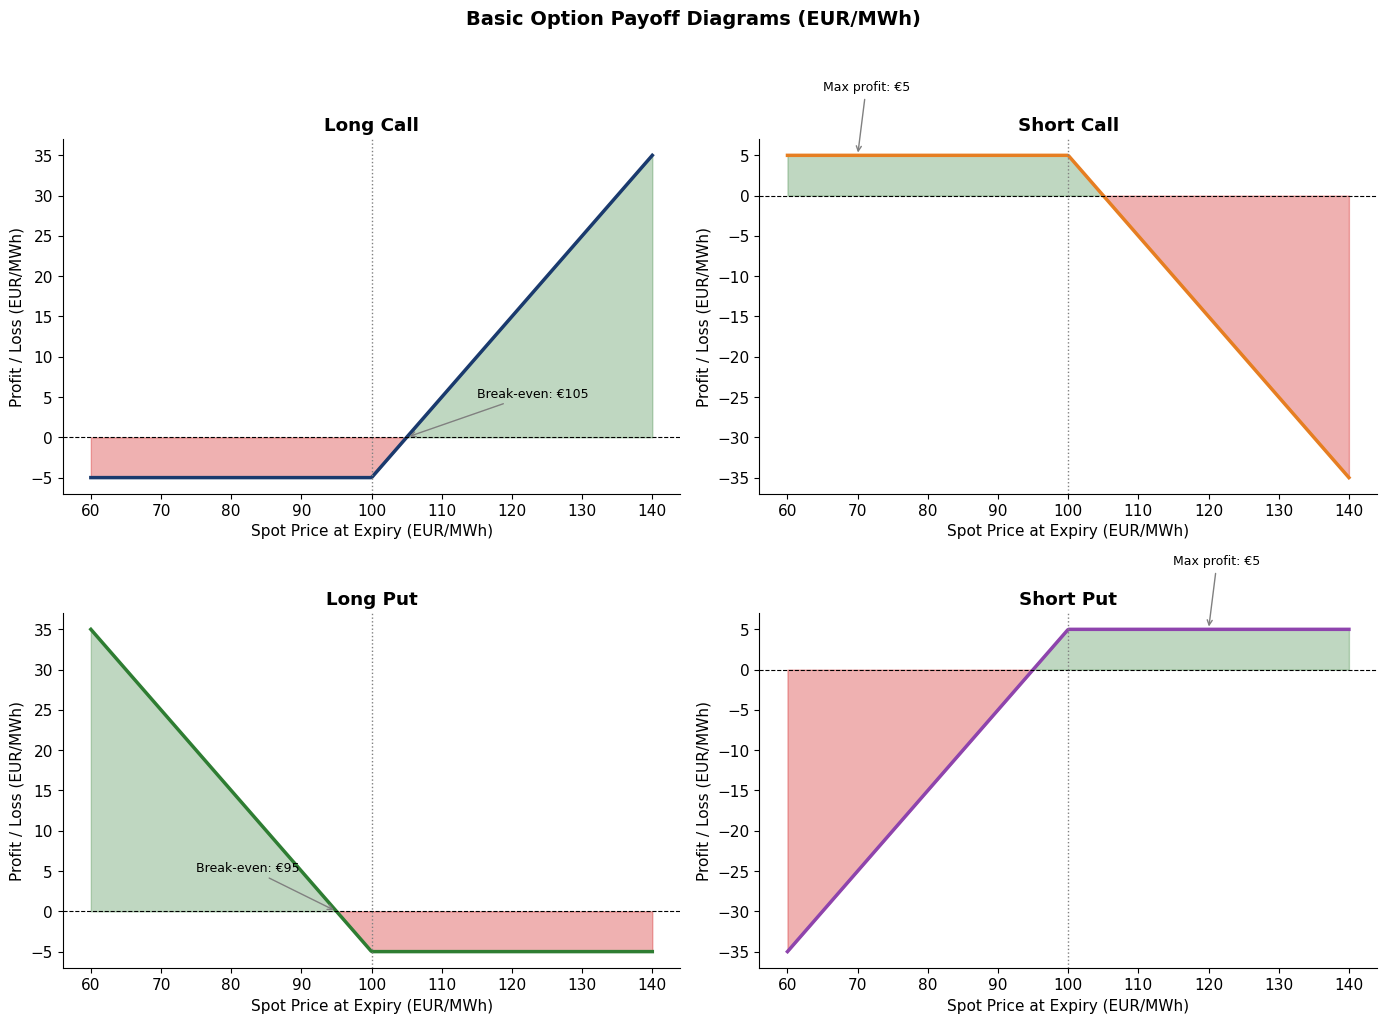

In [4]:
# Figure 1: Basic Option Positions (2x2)
fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))

# Helper function for consistent plotting
def plot_payoff(ax, S, payoff, title, color, K_val):
    ax.plot(S, payoff, color=color, linewidth=2.5)
    ax.fill_between(S, payoff, 0, where=(payoff > 0),
                    color=COLORS['green'], alpha=0.3)
    ax.fill_between(S, payoff, 0, where=(payoff < 0),
                    color=COLORS['red'], alpha=0.3)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.axvline(K_val, color=COLORS['gray'], linestyle=':', linewidth=1,
               label=f'K=€{K_val}')
    ax.set_xlabel('Spot Price at Expiry (EUR/MWh)')
    ax.set_ylabel('Profit / Loss (EUR/MWh)')
    ax.set_title(title, fontweight='bold')

# Long Call
plot_payoff(axes1[0, 0], S, long_call, 'Long Call', COLORS['blue'], K)
axes1[0, 0].annotate(f'Break-even: €{K + call_prem}', 
                     xy=(K + call_prem, 0), xytext=(K + 15, 5),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

# Short Call
plot_payoff(axes1[0, 1], S, short_call, 'Short Call', COLORS['orange'], K)
axes1[0, 1].annotate(f'Max profit: €{call_prem}', 
                     xy=(70, call_prem), xytext=(65, call_prem + 8),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

# Long Put
plot_payoff(axes1[1, 0], S, long_put, 'Long Put', COLORS['green'], K)
axes1[1, 0].annotate(f'Break-even: €{K - put_prem}', 
                     xy=(K - put_prem, 0), xytext=(K - 25, 5),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

# Short Put
plot_payoff(axes1[1, 1], S, short_put, 'Short Put', COLORS['purple'], K)
axes1[1, 1].annotate(f'Max profit: €{put_prem}', 
                     xy=(120, put_prem), xytext=(115, put_prem + 8),
                     fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'))

fig1.suptitle('Basic Option Payoff Diagrams (EUR/MWh)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig1, 'option_payoff.pdf')
plt.show()

Saved: option_strategies.pdf


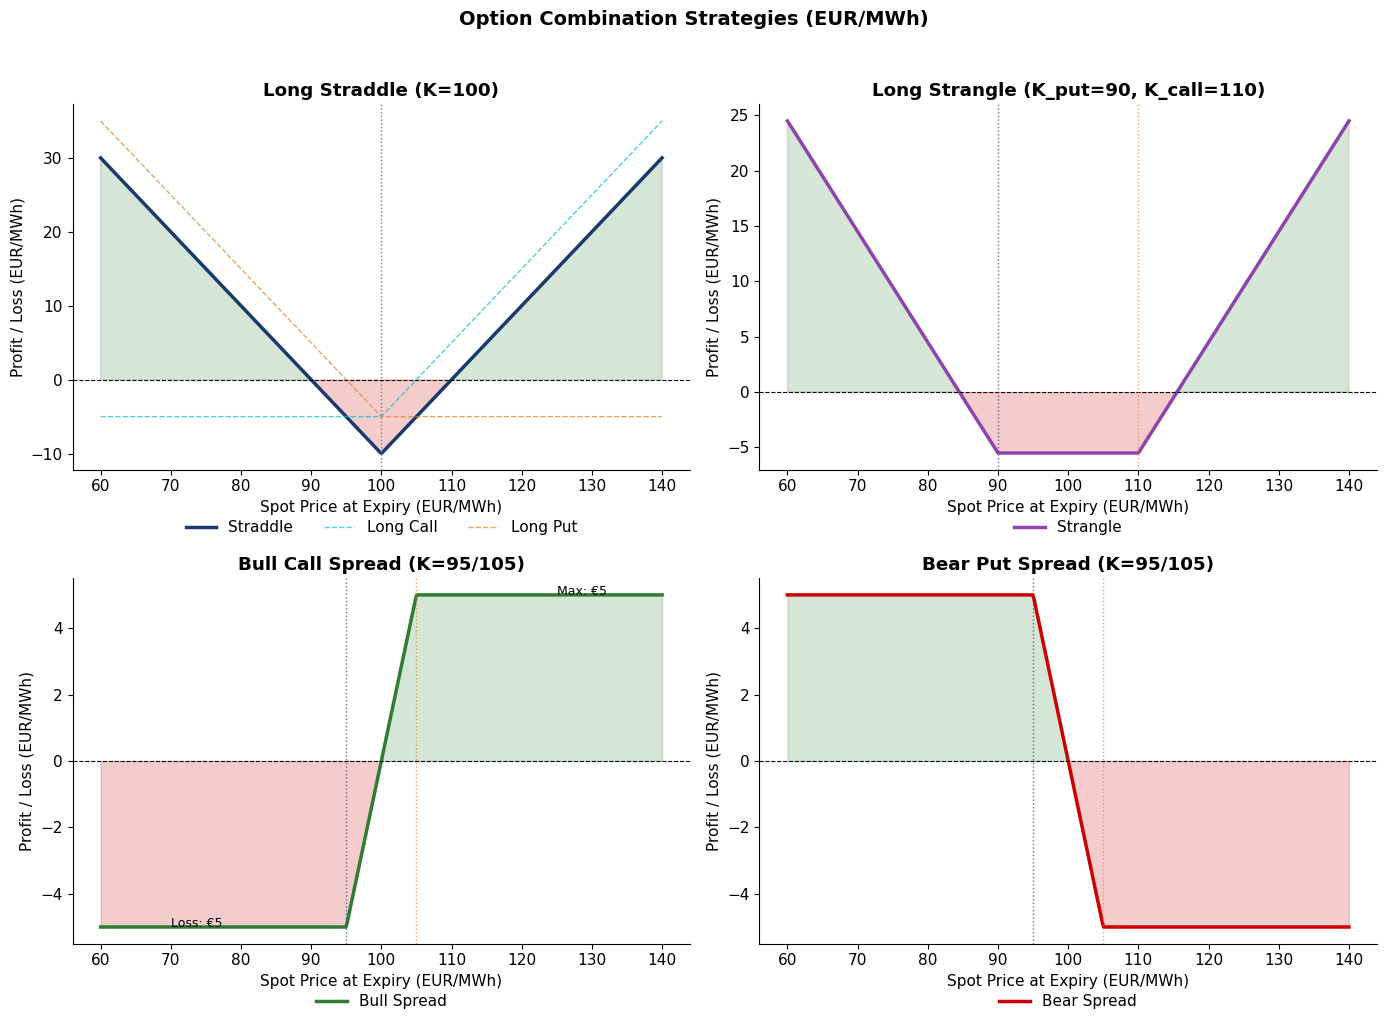

In [5]:
# Figure 2: Advanced Strategies (2x2)

# Straddle: Long Call + Long Put (same strike)
straddle = long_call + long_put

# Strangle: Long OTM Call + Long OTM Put (different strikes)
K_call_otm = 110
K_put_otm = 90
call_prem_otm = 3
put_prem_otm = 2.5
strangle = (call_payoff(S, K_call_otm, call_prem_otm, 'long') + 
            put_payoff(S, K_put_otm, put_prem_otm, 'long'))

# Bull Call Spread: Long lower K call, Short higher K call
K_low = 95
K_high = 105
prem_low = 8
prem_high = 3
bull_spread = (call_payoff(S, K_low, prem_low, 'long') + 
               call_payoff(S, K_high, prem_high, 'short'))

# Bear Put Spread: Long higher K put, Short lower K put
prem_put_high = 7
prem_put_low = 2
bear_spread = (put_payoff(S, K_high, prem_put_high, 'long') + 
               put_payoff(S, K_low, prem_put_low, 'short'))

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))

# Straddle
ax = axes2[0, 0]
ax.plot(S, straddle, color=COLORS['blue'], linewidth=2.5, label='Straddle')
ax.plot(S, long_call, '--', color=COLORS['cyan'], linewidth=1, alpha=0.7, label='Long Call')
ax.plot(S, long_put, '--', color=COLORS['orange'], linewidth=1, alpha=0.7, label='Long Put')
ax.fill_between(S, straddle, 0, where=(straddle > 0), color=COLORS['green'], alpha=0.2)
ax.fill_between(S, straddle, 0, where=(straddle < 0), color=COLORS['red'], alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(K, color=COLORS['gray'], linestyle=':', linewidth=1)
ax.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax.set_ylabel('Profit / Loss (EUR/MWh)')
ax.set_title(f'Long Straddle (K={K})', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Strangle
ax = axes2[0, 1]
ax.plot(S, strangle, color=COLORS['purple'], linewidth=2.5, label='Strangle')
ax.fill_between(S, strangle, 0, where=(strangle > 0), color=COLORS['green'], alpha=0.2)
ax.fill_between(S, strangle, 0, where=(strangle < 0), color=COLORS['red'], alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(K_put_otm, color=COLORS['blue'], linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(K_call_otm, color=COLORS['orange'], linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax.set_ylabel('Profit / Loss (EUR/MWh)')
ax.set_title(f'Long Strangle (K_put={K_put_otm}, K_call={K_call_otm})', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)

# Bull Call Spread
ax = axes2[1, 0]
ax.plot(S, bull_spread, color=COLORS['green'], linewidth=2.5, label='Bull Spread')
ax.fill_between(S, bull_spread, 0, where=(bull_spread > 0), color=COLORS['green'], alpha=0.2)
ax.fill_between(S, bull_spread, 0, where=(bull_spread < 0), color=COLORS['red'], alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(K_low, color=COLORS['blue'], linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(K_high, color=COLORS['orange'], linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax.set_ylabel('Profit / Loss (EUR/MWh)')
ax.set_title(f'Bull Call Spread (K={K_low}/{K_high})', fontweight='bold')
max_profit = K_high - K_low - (prem_low - prem_high)
max_loss = prem_low - prem_high
ax.annotate(f'Max: €{max_profit:.0f}', xy=(125, max_profit), fontsize=9)
ax.annotate(f'Loss: €{max_loss:.0f}', xy=(70, -max_loss), fontsize=9)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)

# Bear Put Spread
ax = axes2[1, 1]
ax.plot(S, bear_spread, color=COLORS['red'], linewidth=2.5, label='Bear Spread')
ax.fill_between(S, bear_spread, 0, where=(bear_spread > 0), color=COLORS['green'], alpha=0.2)
ax.fill_between(S, bear_spread, 0, where=(bear_spread < 0), color=COLORS['red'], alpha=0.2)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.axvline(K_low, color=COLORS['blue'], linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(K_high, color=COLORS['orange'], linestyle=':', linewidth=1, alpha=0.7)
ax.set_xlabel('Spot Price at Expiry (EUR/MWh)')
ax.set_ylabel('Profit / Loss (EUR/MWh)')
ax.set_title(f'Bear Put Spread (K={K_low}/{K_high})', fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False)

fig2.suptitle('Option Combination Strategies (EUR/MWh)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig2, 'option_strategies.pdf')
plt.show()

In [6]:
# Summary table
print("=" * 70)
print("OPTION STRATEGY SUMMARY (EUR/MWh)")
print("=" * 70)
print("\n{:<20} {:<25} {:<25}".format("Strategy", "Max Profit", "Max Loss"))
print("-" * 70)
print("{:<20} {:<25} {:<25}".format("Long Call", "Unlimited", f"€{call_prem} (premium)"))
print("{:<20} {:<25} {:<25}".format("Short Call", f"€{call_prem} (premium)", "Unlimited"))
print("{:<20} {:<25} {:<25}".format("Long Put", f"€{K - put_prem} (if S=0)", f"€{put_prem} (premium)"))
print("{:<20} {:<25} {:<25}".format("Short Put", f"€{put_prem} (premium)", f"€{K - put_prem} (if S=0)"))
print("-" * 70)
straddle_cost = call_prem + put_prem
print("{:<20} {:<25} {:<25}".format("Long Straddle", "Unlimited", f"€{straddle_cost} (both prems)"))
strangle_cost = call_prem_otm + put_prem_otm
print("{:<20} {:<25} {:<25}".format("Long Strangle", "Unlimited", f"€{strangle_cost} (both prems)"))
bull_cost = prem_low - prem_high
bull_max = K_high - K_low - bull_cost
print("{:<20} {:<25} {:<25}".format("Bull Call Spread", f"€{bull_max:.0f}", f"€{bull_cost} (net debit)"))
bear_cost = prem_put_high - prem_put_low
bear_max = K_high - K_low - bear_cost
print("{:<20} {:<25} {:<25}".format("Bear Put Spread", f"€{bear_max:.0f}", f"€{bear_cost} (net debit)"))

OPTION STRATEGY SUMMARY (EUR/MWh)

Strategy             Max Profit                Max Loss                 
----------------------------------------------------------------------
Long Call            Unlimited                 €5 (premium)             
Short Call           €5 (premium)              Unlimited                
Long Put             €95 (if S=0)              €5 (premium)             
Short Put            €5 (premium)              €95 (if S=0)             
----------------------------------------------------------------------
Long Straddle        Unlimited                 €10 (both prems)         
Long Strangle        Unlimited                 €5.5 (both prems)        
Bull Call Spread     €5                        €5 (net debit)           
Bear Put Spread      €5                        €5 (net debit)           
